# Case 1: Observational Causal Modeling: Activity and Blood Pressure

## Set-up

Imagine you want to give high-quality, data-driven advice to individuals about their activity levels.

You have access to a relatively large retrospective dataset that includes information on

- Detailed dietary intake,
- Physical activity measures,
- Demographics and socioeconomic characteristics,
- Health outcomes such as blood pressure and BMI.

The data are stored in a file named "food-health.csv" (The second code block below downloads this data directly from dropbox.) The associated data dictionary is provided in "data_dictionary.pdata."

---

Suppose you are specifically interested in providing advice around the number of days per week that individuals participate in vigorous physical activity,

    sport_days

and how this relates to systolic blood pressure,

    bp_systolic

You begin by estimating the regression


$$\text{bp\_systolic}_i = \alpha + \beta \cdot \text{sport\_days}_i + \varepsilon_i$$


to understand the association between vigorous activity and systolic blood pressure.

Let's start there.

In [2]:
# Libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [66]:
# Get data from dropbox
# Import data from dropbox
# !wget -O food_health.csv "https://www.dropbox.com/scl/fi/a3jpecmxq1i9tkdesjwtp/food_health.csv?rlkey=ylj48ghu4lvxi89lvupn8k2xn&dl=0"

# Import
data = pd.read_csv("food_health.csv")
print(data.head())

   gr_skim_milk  gr_whole_milk  gr_soy_milk  gr_almond_milk  \
0           0.0           0.00          0.0             0.0   
1           0.0           0.00          0.0             0.0   
2           0.0         533.75          0.0             0.0   
3           0.0           0.00          0.0             0.0   
4           0.0           0.00          0.0             0.0   

   gr_chocolate_milk  gr_yogurt  gr_yogurt_low_fat  gr_greek_yogurt  \
0                0.0        0.0               0.00              0.0   
1                0.0        0.0               0.00              0.0   
2                0.0        0.0               0.00              0.0   
3                0.0        0.0             323.38              0.0   
4                0.0        0.0               0.00              0.0   

   gr_greek_yogurt_low_fat  gr_cream  ...  bp_diastolic  total_cholesterol  \
0                      0.0       0.0  ...          88.0               50.0   
1                      0.0       0.0  

In [4]:
# Summary statistics for two baseline variables
print(data[['bp_systolic', 'sport_days']].describe())

# Need to clean out invalid values (sport_days = 99)
data = data[data['sport_days'] < 99]

# There are also missing values in bp_systolic
# The count is less than the total sample size
data = data[~data['bp_systolic'].isna()]

# Let's check
print('\n')
print(data[['bp_systolic', 'sport_days']].describe())

        bp_systolic    sport_days
count  15345.000000  16484.000000
mean     122.982731      0.732286
std       18.180223      1.741562
min       85.000000      0.000000
25%      110.000000      0.000000
50%      120.000000      0.000000
75%      132.000000      0.000000
max      200.000000     99.000000


        bp_systolic    sport_days
count  15344.000000  15344.000000
mean     122.983055      0.735271
std       18.180770      1.569122
min       85.000000      0.000000
25%      110.000000      0.000000
50%      120.000000      0.000000
75%      132.000000      0.000000
max      200.000000      7.000000


In [5]:
# Simple regression
X = sm.add_constant(data['sport_days'])
y = data['bp_systolic']

model = sm.OLS(y, X).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            bp_systolic   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     369.8
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.90e-81
Time:                        22:54:46   Log-Likelihood:                -66144.
No. Observations:               15344   AIC:                         1.323e+05
Df Residuals:                   15342   BIC:                         1.323e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        124.0906      0.167    744.096      0.0

## Set-up Questions:

**Question 1.** What is the estimated coefficient on `sport_days`? What does it mean mechanically? Is the relationship between `sport_days` and `bp_systolic` statistically significant?

What does the coefficient estimate imply about whether you should recommend increasing vigorous exercise to individuals who wish to lower their systolic blood pressure? Explain.

(HINT: In responding, be sure to think about the fact that the data is observational. Individuals were not randomly assigned different exercise levels.)

**Question 2.** The last line in the regression output reads

> Standard Errors are heteroscedasticity robust (HC3).

Briefly explain what that means and why it is likely important if our goal is to take the statistical conclusion seriously.

(HINT: Any AI can answer this question. It is worth understanding.)

---

## Answers:

**Answer 1.** The estimated coefficient of `sports_days` is `-1.5063` ($\hat{\beta}_\text{sports days} = -1.5063$). It means that for every 1 unit increase in $\text{sports\_days}$, the point prediction for $\text{bp\_systolic}$ goes _down_ by $1.5063$. The confidence interval for `sports_days` is $(-1.660, \enspace -1.353)$ at $95\%$ confidence—not containing $0.0$. Therefore, we conclude that the relationship between `sports_day` and `bp_systolic` is statistically significant.

However, this correlation says _nothing_ on whether vigorous exercise should (or should not) be recommended for lowering one's systolic blood pressure (i.e., **causality**). To determine causality, we have to hold an assumption about the data, _that's outside of the data itself_. In other words, you must assume unconfoundedness: 

> **After accounting on other observed set of characteristics** $X$, a person exercising 4 days/week would have a lower blood pressure compared to if they exercised 0 days/week.

You need to argue that you've removed all such $X$-es (confounders), usually using domain knowledge and/or experiment design.

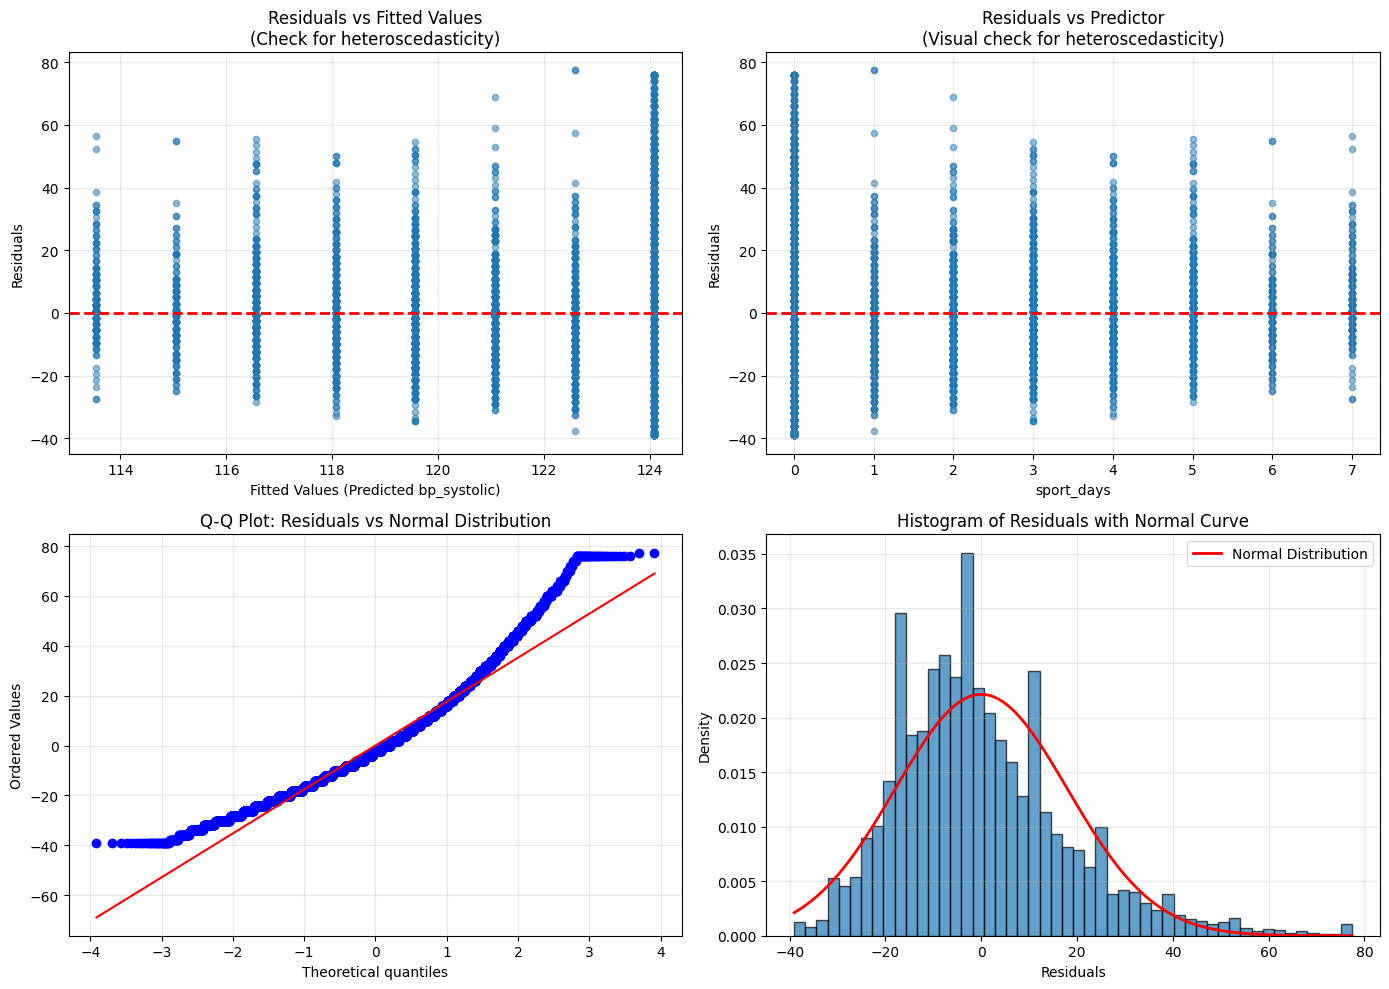


Residual variance by sport_days:
  sport_days = 0: variance = 357.17, n = 11895
  sport_days = 1: variance = 220.26, n = 509
  sport_days = 2: variance = 202.58, n = 699
  sport_days = 3: variance = 206.89, n = 914
  sport_days = 4: variance = 209.91, n = 517
  sport_days = 5: variance = 209.60, n = 472
  sport_days = 6: variance = 191.21, n = 161
  sport_days = 7: variance = 179.93, n = 177


In [8]:
import matplotlib.pyplot as plt
from scipy import stats

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residuals vs Fitted Values
axes[0, 0].scatter(fitted_values, residuals, alpha=0.5, s=20)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values (Predicted bp_systolic)')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values\n(Check for heteroscedasticity)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals vs sport_days (predictor)
axes[0, 1].scatter(data['sport_days'], residuals, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('sport_days')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Predictor\n(Visual check for heteroscedasticity)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: QQ plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: Residuals vs Normal Distribution')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Histogram of residuals with normal curve overlay
axes[1, 1].hist(residuals, bins=50, density=True, alpha=0.7, edgecolor='black')
mu, sigma = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[1, 1].plot(x, stats.norm.pdata(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Histogram of Residuals with Normal Curve')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print variance of residuals by exercise level
print("\nResidual variance by sport_days:")
for days in sorted(data['sport_days'].unique()):
    resid_subset = residuals[data['sport_days'] == days]
    print(f"  sport_days = {days}: variance = {resid_subset.var():.2f}, n = {len(resid_subset)}")

**Answer 2.** The statement means that the dataset contains heteroskedastic residuals: the residual plot shows a "fanning pattern" demonstrating significant change in variance of `bp_systolic` given `sport_days` $\left(\sigma^2(\text{bp\_systolic} \mid \text{sport\_days})\right)$.

In this case, the `sport_days == 0` group have a larger `bp_systolic` variations, compared to groups with higher `sport_days` value.

The reported coefficient $\hat{\beta}_{\text{sport\_days}} = -1.5063$ with 95% CI $(-1.660, -1.353)$ is trustworthy because the `HC3` accounts for this heteroscedasticity.

If heteroscedasticity is present but we used "ordinary" (_non_-heteroscedasticity robust) OLS standard errors, our confidence intervals and p-values are **invalid**:
- Where variance is relatively larger, our confidence intervals will be too narrow (false precision), or
- Where variance is relatively smaller, our confidence intervals would've been too wide (false conservatism).

## Main Question Prompt

Your goal is now to do the best you can, using these data, to understand the *causal* effect of vigorous activity (as measured by `sport_days`) on health outcomes. You may focus on `bp_systolic` or choose another outcome (or combination of outcomes). You should justify your choice.

Start by examining the available variables and postulating a directed acyclic graph (DAG) that would allow you to learn the causal effect of `sport_days` on your chosen outcome by conditioning on an appropriate subset of the observed variables.

You should provide a rational argument for why your proposed DAG is a sensible starting point. Your argument does not need to be watertight (it won't be, given the data you have), but it should be logically coherent. For example:

*   Do not condition on outcomes.
*   Justify any included arrows.
*   Justify why certain arrows are excluded.
*   Use sensible groupings of variables where appropriate (e.g., it is not necessary to include a separate node for every food item if you decide that "diet" can be treated as a grouped input).

---

**Question 3.** Provide a drawing of your DAG and explain the underlying rationale.

---

You should now use debiased machine learning (DML) to estimate a partially linear model coefficient in which your chosen outcome is the dependent variable and `sport_days` is the treatment variable, controlling for confounding variables as indicated by your DAG.

---

**Question 4.** Clean the data.

We resolved two data quality issues in our setup. Before estimating any further models, inspect any variables that you intend to use and resolve any issues that you find.

Carefully document everything you do at this stage (e.g. dropping observations, imputing missing variables, variable transformations).

If you do any imputations or transformations, be sure that you do so in a way that avoids data leakage that could contaminate the DML estimation procedure.

---

**Question 5.** Estimate the partially linear regression coefficient using DML.

DML involves building predictive models and cross-fitting. Explain:

* What models were considered.
* How cross-fitting folds were constructed.
* What your final models are
* Why you made these choices

Provide the final estimated effect, its standard error, and explain how to interpret the result.

---

**Question 6.** Finally, and most importantly, build an explanation that you could present to a group of clinicians.

Imagine the clinicians care about giving data-driven advice to patients but are uncomfortable with providing advice they don't understand or can't explain. That is, your explanation should

* Clearly state the conclusion.
* Describe the assumptions under which your estimates have a causal interpretation.
* Discuss important confounders (if any) identified in the prediction steps of DML.
* Highlight relevant caveats.

One natural caveat to address is *heterogeneity*: up to this point, the prompt has asked for a single summary effect. Be prepared to discuss whether the effect may differ across different (groups of) individuals and, if time permits, explore some potential sources of heterogeneity.

This part of the solution should be provided as a slide deck (and notes) suitable for a 10-minute presentation.

In [81]:
print("="*80)
print("AVAILABLE VARIABLES IN DATASET")
print("="*80)

data.info()
#for i, col in enumerate(data.columns, 1):
#    print(f"{i:3d}. {col}")

print(f"\nTotal variables: {len(data.columns)}")
print("="*80)

AVAILABLE VARIABLES IN DATASET
<class 'pandas.DataFrame'>
RangeIndex: 16484 entries, 0 to 16483
Columns: 656 entries, gr_skim_milk to heart_risk
dtypes: float64(342), int64(310), str(4)
memory usage: 82.5 MB

Total variables: 656


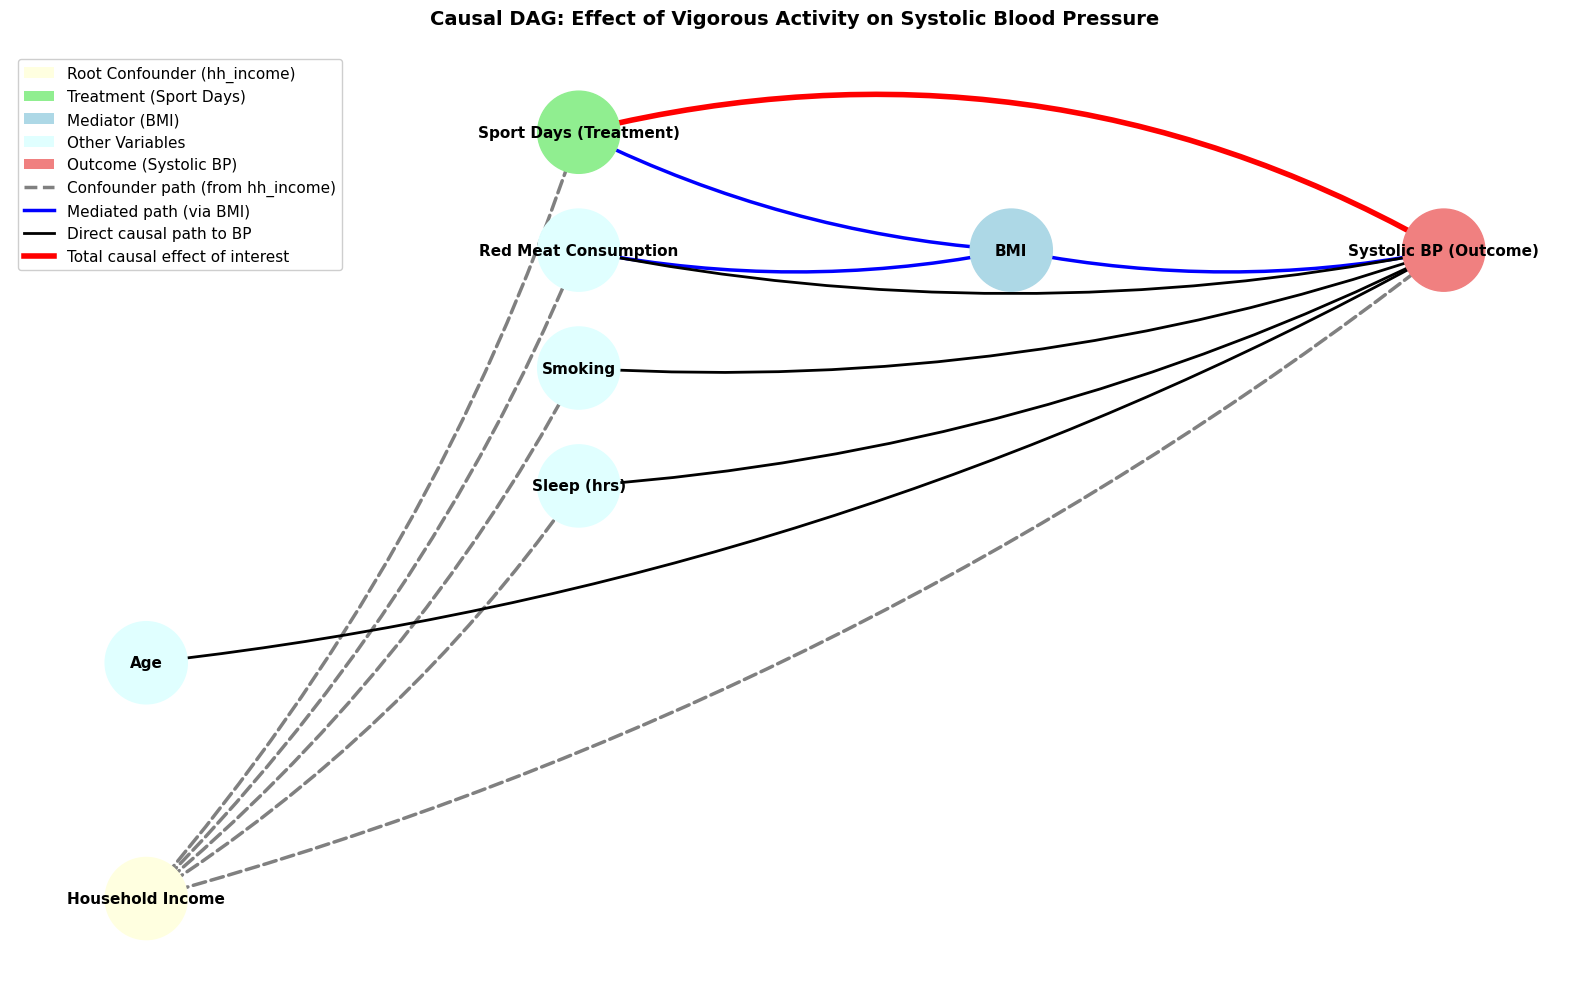

In [156]:
G = nx.DiGraph()

# Define nodes
nodes = {
    'age': 'Age',
    'hh_income': 'Household Income',
    'sport_days': 'Sport Days (Treatment)',
    'red_meat_all': 'Red Meat Consumption',
    'smoker': 'Smoking',
    'sleep_hs': 'Sleep (hrs)',
    'bmi': 'BMI',
    'bp_systolic': 'Systolic BP (Outcome)'
}

G.add_nodes_from(nodes.keys())

edges = [
    # Root confounder affects multiple paths
    ('hh_income', 'sport_days'),
    ('hh_income', 'red_meat_all'),
    ('hh_income', 'smoker'),
    ('hh_income', 'sleep_hs'),
    ('hh_income', 'bp_systolic'),
    
    # Mediating paths
    ('red_meat_all', 'bmi'),
    ('sport_days', 'bmi'),
    
    # Direct causes of BP
    ('smoker', 'bp_systolic'),
    ('sleep_hs', 'bp_systolic'),
    ('red_meat_all', 'bp_systolic'),
    ('sport_days', 'bp_systolic'),  # Causal effect of interest
    ('bmi', 'bp_systolic'),
    ('age', 'bp_systolic')
]

G.add_edges_from(edges)

# Position nodes in logical layers
pos = {
    'age': (0, -3),
    'hh_income': (0, -5),
    'sport_days': (1.5, 1.5),
    'red_meat_all': (1.5, 0.5),
    'smoker': (1.5, -0.5),
    'sleep_hs': (1.5, -1.5),
    'bmi': (3, 0.5),
    'bp_systolic': (4.5, 0.5)
}

# Create figure
fig, ax = plt.subplots(figsize=(16, 10))

# Categorize edges
confounder_edges = [
    ('hh_income', 'sport_days'),
    ('hh_income', 'red_meat_all'),
    ('hh_income', 'smoker'),
    ('hh_income', 'sleep_hs'),
    ('hh_income', 'bp_systolic')
]

mediator_edges = [
    ('red_meat_all', 'bmi'),
    ('sport_days', 'bmi'),
    ('bmi', 'bp_systolic'),
]

direct_cause_edges = [
    ('smoker', 'bp_systolic'),
    ('sleep_hs', 'bp_systolic'),
    ('red_meat_all', 'bp_systolic'),
    ('age', 'bp_systolic')
]

causal_edge = [('sport_days', 'bp_systolic')]

# Draw edges by type
# Confounder edges (gray, dashed)
nx.draw_networkx_edges(G, pos, edgelist=confounder_edges, 
                       edge_color='gray', style='dashed', width=2.5, 
                       arrows=True, arrowsize=18, arrowstyle='->', ax=ax,
                       connectionstyle="arc3,rad=0.1")

# Mediator edges (blue, solid)
nx.draw_networkx_edges(G, pos, edgelist=mediator_edges, 
                       edge_color='blue', style='solid', width=2.5, 
                       arrows=True, arrowsize=18, arrowstyle='->', ax=ax,
                       connectionstyle="arc3,rad=0.1")

# Direct cause edges (black, solid)
nx.draw_networkx_edges(G, pos, edgelist=direct_cause_edges, 
                       edge_color='black', style='solid', width=2, 
                       arrows=True, arrowsize=18, arrowstyle='->', ax=ax,
                       connectionstyle="arc3,rad=0.1")

# Causal edge of interest (red, thick)
nx.draw_networkx_edges(G, pos, edgelist=causal_edge, 
                       edge_color='red', width=4, 
                       arrows=True, arrowsize=22, arrowstyle='->', ax=ax,
                       connectionstyle="arc3,rad=-0.2")

# Node colors
node_colors = []
for node in G.nodes():
    if node == 'sport_days':
        node_colors.append('lightgreen')  # Treatment
    elif node == 'bp_systolic':
        node_colors.append('lightcoral')  # Outcome
    elif node == 'hh_income':
        node_colors.append('lightyellow')  # Root confounder
    elif node == 'bmi':
        node_colors.append('lightblue')   # Mediator
    else:
        node_colors.append('lightcyan')   # Other variables

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3500, ax=ax)
nx.draw_networkx_labels(G, pos, labels=nodes, font_size=11, font_weight='bold', ax=ax)

ax.set_title('Causal DAG: Effect of Vigorous Activity on Systolic Blood Pressure', 
             fontsize=14, fontweight='bold', pad=20)
ax.axis('off')

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='lightyellow', label='Root Confounder (hh_income)'),
    Patch(facecolor='lightgreen', label='Treatment (Sport Days)'),
    Patch(facecolor='lightblue', label='Mediator (BMI)'),
    Patch(facecolor='lightcyan', label='Other Variables'),
    Patch(facecolor='lightcoral', label='Outcome (Systolic BP)'),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=2.5, label='Confounder path (from hh_income)'),
    Line2D([0], [0], color='blue', linewidth=2.5, label='Mediated path (via BMI)'),
    Line2D([0], [0], color='black', linewidth=2, label='Direct causal path to BP'),
    Line2D([0], [0], color='red', linewidth=4, label='Total causal effect of interest'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.95)

plt.tight_layout()
plt.savefig('causal_dag_updated.png', dpi=150, bbox_inches='tight')
plt.show()

### Root Confounder: Household Income

Household income affects almost everything:

- `hh_income` → `sport_days`: Wealthier people have time, money, and safe neighborhoods to exercise
- `hh_income` → `red_meat_all`: Wealthier people afford more red meat
- `hh_income` → `smoker`: Poorer people smoke more
- `hh_income` → `sleep_hs`: Wealthier people sleep longer (less stress, better housing)
- `hh_income` → `bp_systolic`: Wealthy people have lower BP overall

People exercise more AND have lower BP partly because they're wealthy, not just because they exercise.

### More Confounders

First, and most simply, `age` affects `bp_systolic`.

More interestingly, these are the non-causal ways that `sport_days` and `bp_systolic` get correlated through `hh_income`:

- `income` → `sport_days` AND `income` → bp_systolic (direct confounding)
- `hh_income` → `red_meat_all` → `bp_systolic` (diet pathway)
- `hh_income` → `red_meat_all` → `bmi` → `bp_systolic` (weight pathway)
- `hh_income` → `smoker` → `bp_systolic` (smoking pathway)
- `hh_income` → `sleep_hs` → `bp_systolic` (sleep pathway)

**Solution:** Condition on income (and other variables affected by income) to close these backdoors.

### Mediating Paths (Part of the Causal Effect)

These are ways exercise causally affects BP:

- `sport_days` → `bmi` → `bp_systolic`: Exercise reduces weight, which lowers BP
- `sport_days` → `bp_systolic`:** Exercise directly improves heart function, lowering BP

If we want to quantify _total_ effect, no need to condition on `bmi`. If we want to quantify direct causal link, condition `bmi`.

In [163]:
# Select only relevant variables
data = pd.read_csv("food_health.csv")

variables = ['bp_systolic', 'sport_days', 'hh_income', 'red_meat_all',
             'bmi', 'smoker', 'sleep_hs', 'age']

data_clean = data[variables].dropna()
data_clean.describe()

,bp_systolic,sport_days,hh_income,red_meat_all,bmi,smoker,sleep_hs,age
count,14504.000000,14504.000000,14504.000000,14504.000000,14504.000000,14504.000000,14504.000000,14504.000000
mean,122.947945,0.746553,7.580116,0.661680,28.863143,0.199462,6.931881,47.226972
std,18.059269,1.770932,3.609660,0.753894,6.895261,0.399610,2.804370,18.443749
min,85.000000,0.000000,1.000000,0.000000,13.182090,0.000000,2.000000,18.000000
25%,110.000000,0.000000,5.000000,0.000000,24.005227,0.000000,6.000000,31.000000
50%,120.000000,0.000000,7.000000,1.000000,27.742643,0.000000,7.000000,46.500000
75%,132.000000,0.000000,12.000000,1.000000,32.332158,0.000000,8.000000,62.000000
max,200.000000,99.000000,13.000000,6.000000,82.103317,1.000000,99.000000,80.000000


In [161]:
# Remove rows with missing bp_systolic values 
data_clean = data_clean[~data_clean['bp_systolic'].isna()]

# Check for outliers and invalid data
print("\n" + "="*80)
print("OUTLIER & VALIDITY CHECK")
print("="*80)

print("\nsport_days (0-7):")
print(f"  Min: {data_clean['sport_days'].min()}, Max: {data_clean['sport_days'].max()}")
invalid_sport = (data_clean['sport_days'] < 0) | (data_clean['sport_days'] > 7)
print(f"  Invalid values: {invalid_sport.sum()}")

print("\nbmi (12-60 kg/m²):")
print(f"  Min: {data_clean['bmi'].min():.1f}, Max: {data_clean['bmi'].max():.1f}")
invalid_bmi = (data_clean['bmi'] < 12) | (data_clean['bmi'] > 60)
print(f"  Invalid values: {invalid_bmi.sum()}")

print("\nsleep (0-24 hours):")
print(f"  Min: {data_clean['sleep_hs'].min():.1f}, Max: {data_clean['sleep_hs'].max():.1f}")
invalid_sleep = (data_clean['sleep_hs'] < 0) | (data_clean['sleep_hs'] > 24)
print(f"  Invalid values: {invalid_sleep.sum()}")

print("\nage (0-100 years):")
print(f"  Min: {data_clean['age'].min()}, Max: {data_clean['age'].max()}")
invalid_age = (data_clean['age'] < 0) | (data_clean['age'] > 120)
print(f"  Invalid values: {invalid_age.sum()}")

print("\nsmoker (0 or 1):")
print(f"  Unique values: {sorted(data_clean['smoker'].unique())}")
invalid_smoker = ~data_clean['smoker'].isin([0, 1])
print(f"  Invalid values: {invalid_smoker.sum()}")


OUTLIER & VALIDITY CHECK

sport_days (0-7):
  Min: 0, Max: 99
  Invalid values: 1

bmi (12-60 kg/m²):
  Min: 13.2, Max: 82.1
  Invalid values: 31

sleep (0-24 hours):
  Min: 2.0, Max: 99.0
  Invalid values: 10

age (0-100 years):
  Min: 18, Max: 80
  Invalid values: 0

smoker (0 or 1):
  Unique values: [np.int64(0), np.int64(1)]
  Invalid values: 0


In [164]:
# Remove all invalid rows
valid_rows = (~invalid_bmi) & (~invalid_sleep) & (~invalid_sport)
data_clean = data_clean[valid_rows].reset_index(drop=True)
data_clean.describe()

,bp_systolic,sport_days,hh_income,red_meat_all,bmi,smoker,sleep_hs,age
count,14462.000000,14462.000000,14462.000000,14462.000000,14462.000000,14462.000000,14462.000000,14462.000000
mean,122.937837,0.741045,7.584705,0.661527,28.779847,0.199557,6.868967,47.238764
std,18.070567,1.573219,3.609124,0.753764,6.671101,0.399682,1.419160,18.449183
min,85.000000,0.000000,1.000000,0.000000,13.182090,0.000000,2.000000,18.000000
25%,110.000000,0.000000,5.000000,0.000000,23.990738,0.000000,6.000000,31.000000
50%,120.000000,0.000000,7.000000,1.000000,27.714961,0.000000,7.000000,47.000000
75%,132.000000,0.000000,12.000000,1.000000,32.286461,0.000000,8.000000,62.000000
max,200.000000,7.000000,13.000000,6.000000,59.664555,1.000000,12.000000,80.000000


In [165]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [167]:
# Define features and target
X = data_clean[['sport_days', 'hh_income', 'red_meat_all', 'bmi', 
                 'smoker', 'sleep_hs', 'age']]
y = data_clean['bp_systolic']

# Create interaction term (age × smoker)
X['age_smoker_interaction'] = X['age'] * X['smoker']

# Initialize K-Fold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Storage for results
ols_results = {'train_r2': [], 'test_r2': [], 'test_rmse': []}
rf_results = {'train_r2': [], 'test_r2': [], 'test_rmse': []}

# Loop over folds
for train_idx, test_idx in kfold.split(X):
    # Split data by fold
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # ===== DATA TRANSFORMATION (after split to avoid leakage) =====
    # Fit scaler on training data only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Convert back to DataFrame for readability (optional)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
    
    # ===== OLS REGRESSION =====
    ols_model = LinearRegression()
    ols_model.fit(X_train_scaled, y_train)
    
    ols_train_pred = ols_model.predict(X_train_scaled)
    ols_test_pred = ols_model.predict(X_test_scaled)
    
    ols_results['train_r2'].append(r2_score(y_train, ols_train_pred))
    ols_results['test_r2'].append(r2_score(y_test, ols_test_pred))
    ols_results['test_rmse'].append(np.sqrt(mean_squared_error(y_test, ols_test_pred)))
    
    # ===== RANDOM FOREST =====
    # No scaling needed for tree-based models, so use original (unscaled) data
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=5,              # Shallow trees limit complexity
        min_samples_leaf=20,      # Require ≥20 samples per leaf
        min_samples_split=40,     # Require ≥40 samples to split
        max_features='sqrt',      # Use sqrt(features) per split (default is 'auto')
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    
    rf_train_pred = rf_model.predict(X_train)
    rf_test_pred = rf_model.predict(X_test)
    
    rf_results['train_r2'].append(r2_score(y_train, rf_train_pred))
    rf_results['test_r2'].append(r2_score(y_test, rf_test_pred))
    rf_results['test_rmse'].append(np.sqrt(mean_squared_error(y_test, rf_test_pred)))

In [174]:
# ===== REFIT OLS ON FULL DATA FOR SUMMARY =====
scaler_final = StandardScaler()
X_scaled_all = scaler_final.fit_transform(X)
X_scaled_all = pd.DataFrame(X_scaled_all, columns=X.columns).reset_index(drop=True)

y_reset = y.reset_index(drop=True)

X_scaled_with_const = sm.add_constant(X_scaled_all)

ols_final = sm.OLS(y_reset, X_scaled_with_const).fit(cov_type='HC3')
print(ols_final.summary())

                            OLS Regression Results                            
Dep. Variable:            bp_systolic   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.231
Method:                 Least Squares   F-statistic:                     526.5
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        02:08:03   Log-Likelihood:                -60476.
No. Observations:               14462   AIC:                         1.210e+05
Df Residuals:                   14453   BIC:                         1.210e+05
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    122

In [169]:
# ===== REFIT RF ON FULL DATA FOR FEATURE IMPORTANCE =====
X_reset = X.reset_index(drop=True)
y_reset = y.reset_index(drop=True)

rf_final = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=20,
    min_samples_split=40,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_reset, y_reset)

importance_df = pd.DataFrame({
    'Feature': X_reset.columns,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nRandom Forest Feature Importance:")
print(importance_df.to_string(index=False))


Random Forest Feature Importance:
               Feature  Importance
                   age    0.683127
                   bmi    0.100533
age_smoker_interaction    0.082359
            sport_days    0.067348
             hh_income    0.041296
                smoker    0.011609
              sleep_hs    0.009157
          red_meat_all    0.004571


In [170]:
# ===== SUMMARIZE RESULTS =====
print("OLS Regression Results (K-Fold CV):")
print(f"  Mean Train R²:  {np.mean(ols_results['train_r2']):.4f} (±{np.std(ols_results['train_r2']):.4f})")
print(f"  Mean Test R²:   {np.mean(ols_results['test_r2']):.4f} (±{np.std(ols_results['test_r2']):.4f})")
print(f"  Mean Test RMSE: {np.mean(ols_results['test_rmse']):.4f} (±{np.std(ols_results['test_rmse']):.4f})")

print("\nRandom Forest Results (K-Fold CV):")
print(f"  Mean Train R²:  {np.mean(rf_results['train_r2']):.4f} (±{np.std(rf_results['train_r2']):.4f})")
print(f"  Mean Test R²:   {np.mean(rf_results['test_r2']):.4f} (±{np.std(rf_results['test_r2']):.4f})")
print(f"  Mean Test RMSE: {np.mean(rf_results['test_rmse']):.4f} (±{np.std(rf_results['test_rmse']):.4f})")

OLS Regression Results (K-Fold CV):
  Mean Train R²:  0.2313 (±0.0027)
  Mean Test R²:   0.2302 (±0.0102)
  Mean Test RMSE: 15.8491 (±0.3195)

Random Forest Results (K-Fold CV):
  Mean Train R²:  0.2293 (±0.0021)
  Mean Test R²:   0.2149 (±0.0062)
  Mean Test RMSE: 16.0061 (±0.3327)


We decided to use OLS for the nuisance parameter estimation in DML because it has a higher $R^2$. On top of it, it produces honest, interpretable residuals.

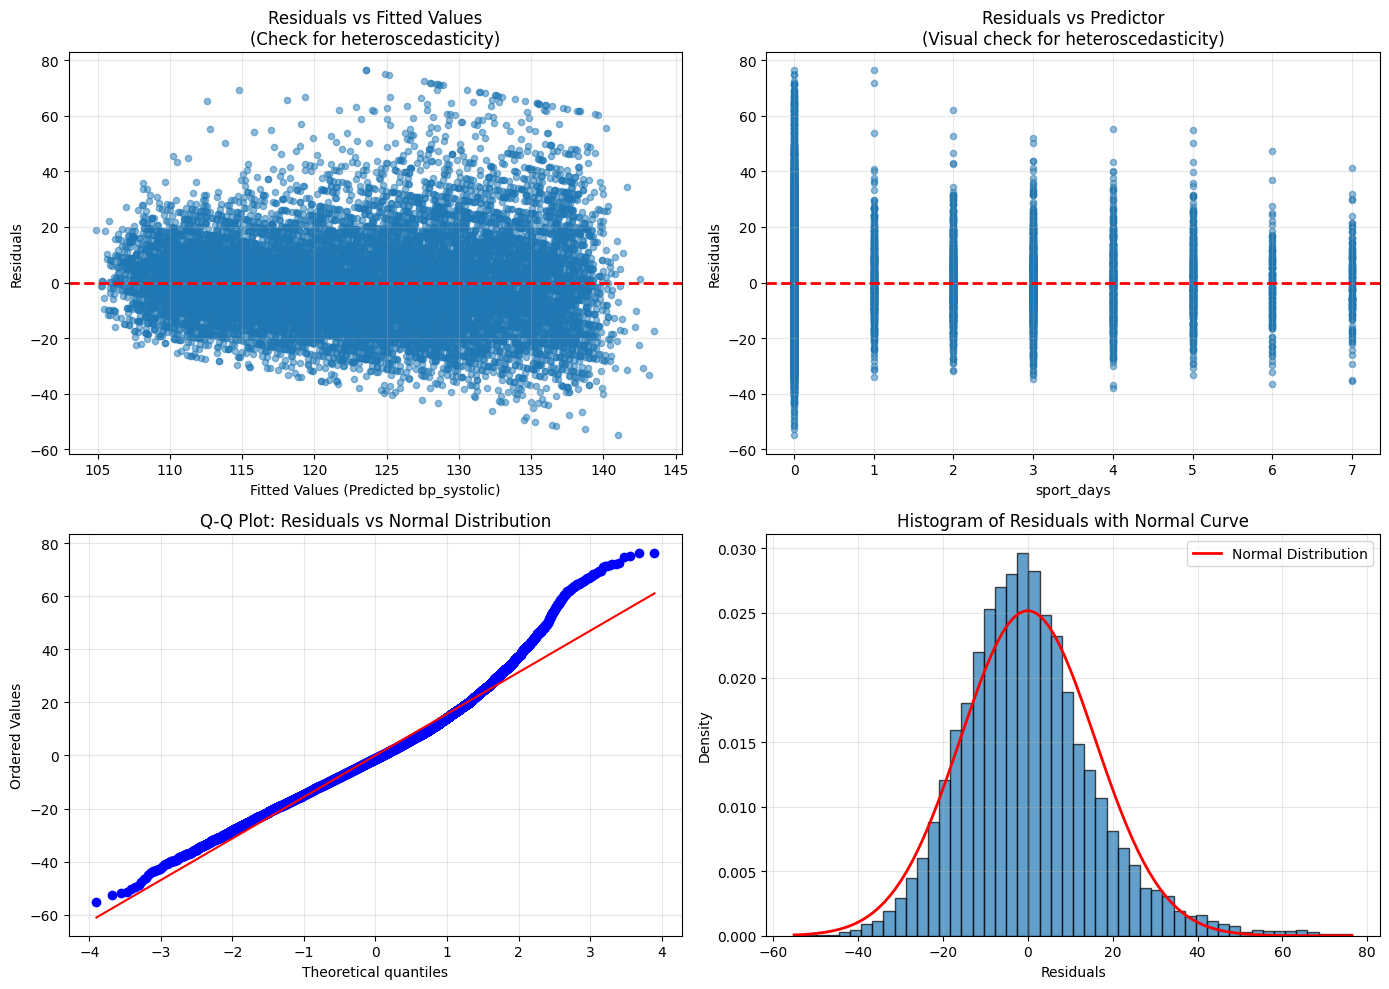


Residual variance by sport_days:
  sport_days = 0: variance = 273.55, n = 11186
  sport_days = 1: variance = 186.13, n = 481
  sport_days = 2: variance = 172.90, n = 662
  sport_days = 3: variance = 165.18, n = 873
  sport_days = 4: variance = 185.51, n = 494
  sport_days = 5: variance = 170.09, n = 447
  sport_days = 6: variance = 179.80, n = 151
  sport_days = 7: variance = 156.49, n = 168


In [176]:
# Get predictions and residuals
fitted_values = ols_final.predict(sm.add_constant(X_scaled_all))
residuals = y_reset - fitted_values

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residuals vs Fitted Values
axes[0, 0].scatter(fitted_values, residuals, alpha=0.5, s=20)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values (Predicted bp_systolic)')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values\n(Check for heteroscedasticity)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals vs sport_days (predictor)
axes[0, 1].scatter(X['sport_days'], residuals, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('sport_days')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Predictor\n(Visual check for heteroscedasticity)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: QQ plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: Residuals vs Normal Distribution')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Histogram of residuals with normal curve overlay
axes[1, 1].hist(residuals, bins=50, density=True, alpha=0.7, edgecolor='black')
mu, sigma = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[1, 1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Histogram of Residuals with Normal Curve')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print variance of residuals by exercise level
print("\nResidual variance by sport_days:")
for days in sorted(X['sport_days'].unique()):
    resid_subset = residuals[X['sport_days'] == days]
    print(f"  sport_days = {days}: variance = {resid_subset.var():.2f}, n = {len(resid_subset)}")

### Run DML

In [178]:
# =============================================================================
# DML 1: TOTAL EFFECT (exclude mediator BMI)
# =============================================================================
T = data_clean['sport_days'].values.reshape(-1, 1)
Y = data_clean['bp_systolic'].values

confounders_total = data_clean[['hh_income', 'red_meat_all', 
                                 'smoker', 'sleep_hs', 'age']].reset_index(drop=True)
confounders_total['age_smoker_interaction'] = confounders_total['age'] * confounders_total['smoker']
X_conf_total = confounders_total.values

n_samples = len(T)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

residuals_Y_total = np.zeros(n_samples)
residuals_T_total = np.zeros(n_samples)

for train_idx, test_idx in kfold.split(X_conf_total):
    X_train_conf = X_conf_total[train_idx]
    X_test_conf = X_conf_total[test_idx]
    
    T_train, T_test = T[train_idx], T[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    
    outcome_model = LinearRegression()
    outcome_model.fit(X_train_conf, Y_train)
    Y_pred_test = outcome_model.predict(X_test_conf)
    residuals_Y_total[test_idx] = Y_test - Y_pred_test
    
    treatment_model = LinearRegression()
    treatment_model.fit(X_train_conf, T_train.ravel())
    T_pred_test = treatment_model.predict(X_test_conf)
    residuals_T_total[test_idx] = T_test.ravel() - T_pred_test

dml_total = LinearRegression()
dml_total.fit(residuals_T_total.reshape(-1, 1), residuals_Y_total)

print("="*70)
print("DML: TOTAL EFFECT of sport_days on bp_systolic")
print("="*70)
print(f"Coefficient (all pathways): {dml_total.coef_[0]:.4f}")
print(f"Interpretation: A 1-unit increase in sport_days changes bp_systolic")
print(f"                by {dml_total.coef_[0]:.4f} mmHg (through all channels)")

# =============================================================================
# DML 2: DIRECT EFFECT (include mediator BMI)
# =============================================================================
confounders_direct = data_clean[['hh_income', 'red_meat_all', 'bmi',
                                  'smoker', 'sleep_hs', 'age']].reset_index(drop=True)
confounders_direct['age_smoker_interaction'] = confounders_direct['age'] * confounders_direct['smoker']
X_conf_direct = confounders_direct.values

residuals_Y_direct = np.zeros(n_samples)
residuals_T_direct = np.zeros(n_samples)

for train_idx, test_idx in kfold.split(X_conf_direct):
    X_train_conf = X_conf_direct[train_idx]
    X_test_conf = X_conf_direct[test_idx]
    
    T_train, T_test = T[train_idx], T[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    
    outcome_model = LinearRegression()
    outcome_model.fit(X_train_conf, Y_train)
    Y_pred_test = outcome_model.predict(X_test_conf)
    residuals_Y_direct[test_idx] = Y_test - Y_pred_test
    
    treatment_model = LinearRegression()
    treatment_model.fit(X_train_conf, T_train.ravel())
    T_pred_test = treatment_model.predict(X_test_conf)
    residuals_T_direct[test_idx] = T_test.ravel() - T_pred_test

dml_direct = LinearRegression()
dml_direct.fit(residuals_T_direct.reshape(-1, 1), residuals_Y_direct)

print("\n" + "="*70)
print("DML: DIRECT EFFECT of sport_days on bp_systolic")
print("="*70)
print(f"Coefficient (excluding BMI pathway): {dml_direct.coef_[0]:.4f}")
print(f"Interpretation: A 1-unit increase in sport_days changes bp_systolic")
print(f"                by {dml_direct.coef_[0]:.4f} mmHg (holding BMI constant)")

# =============================================================================
# Decomposition
# =============================================================================
indirect_effect = dml_total.coef_[0] - dml_direct.coef_[0]

print("\n" + "="*70)
print("MEDIATION DECOMPOSITION")
print("="*70)
print(f"Total effect:      {dml_total.coef_[0]:+.4f} mmHg")
print(f"Direct effect:     {dml_direct.coef_[0]:+.4f} mmHg")
print(f"Indirect (via BMI): {indirect_effect:+.4f} mmHg")
print(f"Proportion via BMI: {100*indirect_effect/dml_total.coef_[0]:.1f}%")

DML: TOTAL EFFECT of sport_days on bp_systolic
Coefficient (all pathways): 0.0418
Interpretation: A 1-unit increase in sport_days changes bp_systolic
                by 0.0418 mmHg (through all channels)

DML: DIRECT EFFECT of sport_days on bp_systolic
Coefficient (excluding BMI pathway): 0.1474
Interpretation: A 1-unit increase in sport_days changes bp_systolic
                by 0.1474 mmHg (holding BMI constant)

MEDIATION DECOMPOSITION
Total effect:      +0.0418 mmHg
Direct effect:     +0.1474 mmHg
Indirect (via BMI): -0.1055 mmHg
Proportion via BMI: -252.4%


In [179]:
# =============================================================================
# Statistical significance of DML estimates
# =============================================================================

def compute_dml_se(residuals_Y, residuals_T):
    """Compute standard error for DML coefficient using Neyman orthogonality."""
    n = len(residuals_Y)
    
    # Coefficient
    coef = np.cov(residuals_Y, residuals_T.ravel())[0, 1] / np.var(residuals_T)
    
    # Residuals from final DML regression
    dml_residuals = residuals_Y - coef * residuals_T.ravel()
    
    # Variance of DML residuals
    var_residuals = np.var(dml_residuals)
    var_T = np.var(residuals_T)
    
    # Standard error
    se = np.sqrt(var_residuals / (n * var_T**2))
    
    return coef, se

# Total effect
coef_total, se_total = compute_dml_se(residuals_Y_total, residuals_T_total)
ci_lower_total = coef_total - 1.96 * se_total
ci_upper_total = coef_total + 1.96 * se_total
z_total = coef_total / se_total
p_total = 2 * (1 - stats.norm.cdf(abs(z_total)))

print("="*70)
print("TOTAL EFFECT: Statistical Significance")
print("="*70)
print(f"Coefficient:     {coef_total:+.4f}")
print(f"Std Error:       {se_total:.4f}")
print(f"95% CI:          [{ci_lower_total:.4f}, {ci_upper_total:.4f}]")
print(f"z-statistic:     {z_total:.4f}")
print(f"p-value:         {p_total:.4f}")
print(f"Significant at α=0.05? {p_total < 0.05}")

# Direct effect
coef_direct, se_direct = compute_dml_se(residuals_Y_direct, residuals_T_direct)
ci_lower_direct = coef_direct - 1.96 * se_direct
ci_upper_direct = coef_direct + 1.96 * se_direct
z_direct = coef_direct / se_direct
p_direct = 2 * (1 - stats.norm.cdf(abs(z_direct)))

print("\n" + "="*70)
print("DIRECT EFFECT: Statistical Significance")
print("="*70)
print(f"Coefficient:     {coef_direct:+.4f}")
print(f"Std Error:       {se_direct:.4f}")
print(f"95% CI:          [{ci_lower_direct:.4f}, {ci_upper_direct:.4f}]")
print(f"z-statistic:     {z_direct:.4f}")
print(f"p-value:         {p_direct:.4f}")
print(f"Significant at α=0.05? {p_direct < 0.05}")

# Indirect effect (via delta method approximation)
# Indirect = Total - Direct
coef_indirect = coef_total - coef_direct
se_indirect = np.sqrt(se_total**2 + se_direct**2)  # Approximate (assumes independence)
ci_lower_indirect = coef_indirect - 1.96 * se_indirect
ci_upper_indirect = coef_indirect + 1.96 * se_indirect
z_indirect = coef_indirect / se_indirect
p_indirect = 2 * (1 - stats.norm.cdf(abs(z_indirect)))

print("\n" + "="*70)
print("INDIRECT EFFECT (via BMI): Statistical Significance")
print("="*70)
print(f"Coefficient:     {coef_indirect:+.4f}")
print(f"Std Error:       {se_indirect:.4f}")
print(f"95% CI:          [{ci_lower_indirect:.4f}, {ci_upper_indirect:.4f}]")
print(f"z-statistic:     {z_indirect:.4f}")
print(f"p-value:         {p_indirect:.4f}")
print(f"Significant at α=0.05? {p_indirect < 0.05}")

TOTAL EFFECT: Statistical Significance
Coefficient:     +0.0418
Std Error:       0.0592
95% CI:          [-0.0741, 0.1578]
z-statistic:     0.7070
p-value:         0.4796
Significant at α=0.05? False

DIRECT EFFECT: Statistical Significance
Coefficient:     +0.1474
Std Error:       0.0596
95% CI:          [0.0305, 0.2642]
z-statistic:     2.4725
p-value:         0.0134
Significant at α=0.05? True

INDIRECT EFFECT (via BMI): Statistical Significance
Coefficient:     -0.1055
Std Error:       0.0840
95% CI:          [-0.2701, 0.0590]
z-statistic:     -1.2569
p-value:         0.2088
Significant at α=0.05? False
